# Ekstraksi Fitur Sentinel-2A Berbasis Poligon
## Klasifikasi Penggunaan dan Tutupan Lahan (LULC) Provinsi Jawa Timur

**Deskripsi Proyek:**
Analisis spasial penggunaan lahan dan tutupan lahan (*Land Use / Land Cover* - LULC) di wilayah Jawa Timur menggunakan citra satelit **Sentinel-2A Multispectral Instrument (MSI)** dan data vektor poligon acuan SNI 7645-1:2014.

**Tujuan Ekstraksi Data:**
* Mengidentifikasi dan mengekstrak data dari 6 kelas tutupan lahan utama di Jawa Timur:
  - **Sawah** (`sawah/sawah.shp`)
  - **Bangunan / Lahan Terbangun** (`bangunan/bangunan.shp`)
  - **Mangrove** (`mangrove/mangrove.shp`)
  - **Lahan Hijau / Hutan / Perkebunan** (`lahanhijau/lahanhijau.shp`)
  - **Perairan Terbuka / Laut** (`laut/laut.shp`)
  - **Danau / Waduk / Ranu** (`danau/danau.shp`)
* Menggunakan **pendekatan poligon** (*polygon-based extraction* / segmentasi bidang lahan), di mana setiap poligon mewakili satu unit observasi tutupan lahan yang homogen. Titik representatif di dalam poligon (`representative_point`) diambil untuk mengekstrak nilai spektral.
* Melakukan ekstraksi **10 band spektral asli Sentinel-2A** dan menghitung **8 indeks spektral turunan** standar geospasial (`NDVI`, `NDWI`, `MNDWI`, `NDBI`, `NDRE`, `EVI`, `SAVI`, `BSI`).
* Menggabungkan seluruh data dari ke-6 folder shapefile menjadi **satu dataset terpadu** (`dataset_sentinel2_jatim.csv`) yang memuat kolom identitas (`kelas_id`, `kelas`, `poligon_id`, `lon`, `lat`) dan ke-18 fitur spektral.

---
## Import Pustaka dan Konfigurasi Global
Pustaka yang digunakan mencakup `geopandas` dan `shapely` untuk pengolahan data geospasial vektor poligon, `pandas` dan `numpy` untuk manajemen dataset tabular, `matplotlib` dan `seaborn` untuk visualisasi statistik, serta `folium` untuk pemetaan interaktif satelit.

In [1]:
import os
import sys
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from IPython.display import display, Markdown

import folium
from folium import Element
from folium.plugins import MiniMap

# Konfigurasi gaya visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Semua pustaka berhasil diimpor dengan sukses!")

Semua pustaka berhasil diimpor dengan sukses!


---
## Definisi Kelas Tutupan Lahan dan Jalur Shapefile
Menentukan metadata untuk ke-6 kelas tutupan lahan:
- **Sawah**
- **Bangunan**
- **Mangrove**
- **Lahan Hijau**
- **Perairan Terbuka (Laut)**
- **Danau**

In [2]:
DATA_DIR = "."
CSV_DATASET = "dataset_sentinel2_jatim.csv"
SEED = 42

KELAS = {
    1: {"nama": "Sawah",                   "folder": "sawah",       "file": "sawah",       "warna": "#FFD92F"},
    2: {"nama": "Bangunan",                "folder": "bangunan",    "file": "bangunan",    "warna": "#E41A1C"},
    3: {"nama": "Mangrove",                "folder": "mangrove",    "file": "mangrove",    "warna": "#8E44AD"},
    4: {"nama": "Lahan Hijau",             "folder": "lahanhijau",  "file": "lahanhijau",  "warna": "#2E7D32"},
    5: {"nama": "Perairan Terbuka (Laut)", "folder": "laut",        "file": "laut",        "warna": "#0D47A1"},
    6: {"nama": "Danau",                   "folder": "danau",       "file": "danau",       "warna": "#4FC3F7"},
}

NAMA_KELAS = [v["nama"] for v in KELAS.values()]
WARNA_KELAS = {v["nama"]: v["warna"] for v in KELAS.values()}

print(f"Total kelas yang didefinisikan: {len(KELAS)}")
for k, v in KELAS.items():
    print(f"  ID {k}: {v['nama']:<25} | File target: {v['file']}.shp | Warna: {v['warna']}")

Total kelas yang didefinisikan: 6
  ID 1: Sawah                     | File target: sawah.shp | Warna: #FFD92F
  ID 2: Bangunan                  | File target: bangunan.shp | Warna: #E41A1C
  ID 3: Mangrove                  | File target: mangrove.shp | Warna: #8E44AD
  ID 4: Lahan Hijau               | File target: lahanhijau.shp | Warna: #2E7D32
  ID 5: Perairan Terbuka (Laut)   | File target: laut.shp | Warna: #0D47A1
  ID 6: Danau                     | File target: danau.shp | Warna: #4FC3F7


---
## Pembacaan dan Validasi Data Poligon Shapefile
Setiap file `.shp` dari masing-masing folder kelas dibaca menggunakan GeoPandas.
Proses validasi meliputi:
1. Pengecekan Sistem Referensi Koordinat (CRS) dan standardisasi ke **WGS84 (EPSG:4326)**.
2. Pembersihan geometri yang kosong (*empty geometry*) atau tidak valid menggunakan `buffer(0)`.
3. Perhitungan luas area total poligon (Hektar) menggunakan proyeksi UTM Zona 49S (EPSG:32749).

In [3]:
def cari_shp(nama):
    """Mencari path file .shp di DATA_DIR dan subfoldernya secara case-insensitive."""
    target = nama.lower().replace(" ", "").replace("_", "")
    for root, _, files in os.walk(DATA_DIR):
        for f in files:
            name_clean = f[:-4].lower().replace(" ", "").replace("_", "")
            if f.lower().endswith(".shp") and (name_clean == target or target in name_clean or name_clean in target):
                return os.path.join(root, f)
    raise FileNotFoundError(f"File {nama}.shp tidak ditemukan di '{os.path.abspath(DATA_DIR)}'")

def baca_shp(path):
    """Membaca file shapefile dan menormalkan CRS ke EPSG:4326 WGS84."""
    g = gpd.read_file(path)
    if g.crs is None:
        g = g.set_crs(4326)
    else:
        g = g.to_crs(4326)
    g = g[g.geometry.notnull() & ~g.geometry.is_empty].copy()
    g["geometry"] = g.geometry.apply(lambda x: x if x.is_valid else x.buffer(0))
    return g[["geometry"]].reset_index(drop=True)

jalur_shp = {}
data_poligon = {}
ringkasan_spasial = []

for k, v in KELAS.items():
    path = cari_shp(v["file"])
    jalur_shp[k] = path
    gdf = baca_shp(path)
    data_poligon[k] = gdf
    
    # Hitung luas dalam hektar (UTM 49S)
    try:
        luas_ha = gdf.to_crs(32749).area.sum() / 10000.0
    except Exception:
        luas_ha = np.nan
        
    b = gdf.total_bounds
    ringkasan_spasial.append({
        "ID": k,
        "Kelas": v["nama"],
        "Path Shapefile": path,
        "Jml Poligon": len(gdf),
        "Total Luas (Ha)": round(luas_ha, 2) if not np.isnan(luas_ha) else "-",
        "Bujur Min (BT)": round(b[0], 4),
        "Lintang Min (LS)": round(b[1], 4),
        "Bujur Maks (BT)": round(b[2], 4),
        "Lintang Maks (LS)": round(b[3], 4),
    })

df_ringkasan = pd.DataFrame(ringkasan_spasial).set_index("ID")
display(df_ringkasan)

,Kelas,Path Shapefile,Jml Poligon,Total Luas (Ha),Bujur Min (BT),Lintang Min (LS),Bujur Maks (BT),Lintang Maks (LS)
ID,,,,,,,,
1,Sawah,.\sawah\sawah.shp,50,4198.58,111.9327,-8.1329,113.8731,-6.8441
2,Bangunan,.\bangunan\bangunan.shp,50,2413.63,111.1959,-8.0363,113.7771,-7.1143
3,Mangrove,.\mangrove\mangrove.shp,50,1207.91,112.8013,-7.6327,112.9523,-7.2445
4,Lahan Hijau,.\lahanhijau\lahanhijau.shp,50,18452.87,110.9931,-8.6062,114.0597,-7.1573
5,Perairan Terbuka (Laut),.\laut\laut.shp,35,19284156.42,110.7162,-9.5742,117.2762,-4.2585
6,Danau,.\danau\danau.shp,50,737.74,111.0199,-8.3613,114.2460,-5.7687


---
## Ekstraksi Titik Koordinat Berbasis Poligon
Untuk setiap poligon, kita mengekstrak titik koordinat bujur (*longitude*) dan lintang (*latitude*):
- Menggunakan `geom.representative_point()` yang menjamin titik koordinat selalu berada **di dalam interior poligon**.
- Pendekatan berbasis poligon ini menghasilkan 1 baris observasi per poligon sehingga dataset terbebas dari bias autokorelasi spasial piksel-piksel yang berdekatan (*spatial autocorrelation*).

In [4]:
daftar_titik = []

for k, v in KELAS.items():
    gdf = data_poligon[k]
    for idx_poly, geom in enumerate(gdf.geometry):
        pt = geom.representative_point()
        daftar_titik.append({
            "kelas_id": k,
            "kelas": v["nama"],
            "poligon_id": idx_poly,
            "lon": pt.x,
            "lat": pt.y
        })

df_titik = pd.DataFrame(daftar_titik).reset_index(drop=True)
df_titik.index.name = "idx"

print(f"Total poligon terekstraksi dari 6 shapefile: {len(df_titik)}")
rekap_poligon = df_titik.groupby(["kelas_id", "kelas"]).size().to_frame("Jumlah Poligon")
display(rekap_poligon)
display(df_titik.head(10))

Total poligon terekstraksi dari 6 shapefile: 285


,,Jumlah Poligon
kelas_id,kelas,
1,Sawah,50
2,Bangunan,50
3,Mangrove,50
4,Lahan Hijau,50
5,Perairan Terbuka (Laut),35
6,Danau,50


,kelas_id,kelas,poligon_id,lon,lat
idx,,,,,
0,1,Sawah,0,113.868772,-7.018261
1,1,Sawah,1,113.245773,-7.198256
2,1,Sawah,2,112.716742,-7.052929
3,1,Sawah,3,112.720674,-7.107704
4,1,Sawah,4,112.715537,-7.140550
5,1,Sawah,5,112.721893,-7.141569
6,1,Sawah,6,112.725362,-7.138644
7,1,Sawah,7,112.732793,-7.140221
8,1,Sawah,8,112.608181,-7.432008


---
## Deskripsi Fitur Sentinel-2A dan Rumus Indeks Spektral
Dalam penginderaan jauh multispektral, fitur yang diekstraksi terdiri atas **10 Band Reflektansi Permukaan (Bottom-Of-Atmosphere / BOA L2A)** dan **8 Indeks Spektral Turunan**:

### Band Reflektansi Sentinel-2A
| Band | Panjang Gelombang | Resolusi | Karakteristik Utama |
|---|---|---|---|
| `B2` (Blue) | 492 nm | 10 m | Sensitif terhadap hamburan atmosfer dan penetrasi air jernih |
| `B3` (Green) | 560 nm | 10 m | Puncak pantulan klorofil vegetasi & badan air |
| `B4` (Red) | 665 nm | 10 m | Penyerapan klorofil tanaman (kunci NDVI) |
| `B5` (Red Edge 1) | 704 nm | 20 m | Batas serapan merah - pantulan inframerah |
| `B6` (Red Edge 2) | 740 nm | 20 m | Peningkatan reflektansi struktur sel daun |
| `B7` (Red Edge 3) | 783 nm | 20 m | Plateau inframerah dekat |
| `B8` (NIR) | 833 nm | 10 m | Pantulan tertinggi biomassa sel daun |
| `B8A` (Narrow NIR) | 865 nm | 20 m | Deteksi uap air dan kanopi sempit |
| `B11` (SWIR 1) | 1614 nm | 20 m | Sensitif terhadap kelembaban tanaman & lahan terbangun |
| `B12` (SWIR 2) | 2202 nm | 20 m | Deteksi mineral, batuan, dan tanah terbuka |

### Rumus 8 Indeks Spektral
| Fitur | Nama Lengkap | Rumus Matematis | Fungsi Analisis |
|---|---|---|---|
| **`NDVI`** | Normalized Difference Vegetation Index | $\dfrac{B8 - B4}{B8 + B4}$ | Mengukur kehijauan & kerapatan kanopi vegetasi |
| **`NDWI`** | Normalized Difference Water Index (McFeeters) | $\dfrac{B3 - B8}{B3 + B8}$ | Membedakan badan air dengan daratan |
| **`MNDWI`**| Modified NDWI (Xu) | $\dfrac{B3 - B11}{B3 + B11}$ | Membedakan badan air dari lahan terbangun/pemukiman |
| **`NDBI`** | Normalized Difference Built-up Index | $\dfrac{B11 - B8}{B11 + B8}$ | Deteksi konsentrasi bangunan & semen/aspal |
| **`NDRE`** | Normalized Difference Red Edge | $\dfrac{B8 - B5}{B8 + B5}$ | Deteksi klorofil tanaman & kanopi lebat |
| **`EVI`**  | Enhanced Vegetation Index | $2.5 \times \dfrac{B8 - B4}{B8 + 6 \cdot B4 - 7.5 \cdot B2 + 1}$ | Vegetasi lebat dengan koreksi gangguan atmosfer |
| **`SAVI`** | Soil Adjusted Vegetation Index | $1.5 \times \dfrac{B8 - B4}{B8 + B4 + 0.5}$ | Vegetasi dengan koreksi latar belakang tanah ($L=0.5$) |
| **`BSI`**  | Bare Soil Index | $\dfrac{(B11 + B4) - (B8 + B2)}{(B11 + B4) + (B8 + B2)}$ | Identifikasi tanah kosong, pasir, dan lahan kering |

In [5]:
BAND_ASLI = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
INDEKS_SPEKTRAL = ["NDVI", "NDWI", "MNDWI", "NDBI", "NDRE", "EVI", "SAVI", "BSI"]
FITUR_SEMUA = BAND_ASLI + INDEKS_SPEKTRAL

def hitung_indeks_spektral(df_input):
    # Menghitung 8 indeks spektral penginderaan jauh standar
    d = df_input.copy()
    eps = 1e-9  # Nilai epsilon mencegah pembagian dengan nol
    nd = lambda a, b: (a - b) / (a + b + eps)
    
    # 1. NDVI (Vegetasi)
    d["NDVI"]  = nd(d["B8"], d["B4"])
    # 2. NDWI (Badan Air McFeeters)
    d["NDWI"]  = nd(d["B3"], d["B8"])
    # 3. MNDWI (Badan Air Modifikasi Xu)
    d["MNDWI"] = nd(d["B3"], d["B11"])
    # 4. NDBI (Lahan Terbangun)
    d["NDBI"]  = nd(d["B11"], d["B8"])
    # 5. NDRE (Red Edge Klorofil)
    d["NDRE"]  = nd(d["B8"], d["B5"])
    # 6. EVI (Enhanced Vegetation Index)
    d["EVI"]   = 2.5 * (d["B8"] - d["B4"]) / (d["B8"] + 6.0 * d["B4"] - 7.5 * d["B2"] + 1.0 + eps)
    # 7. SAVI (Soil Adjusted Vegetation Index, L=0.5)
    d["SAVI"]  = 1.5 * (d["B8"] - d["B4"]) / (d["B8"] + d["B4"] + 0.5 + eps)
    # 8. BSI (Bare Soil Index)
    d["BSI"]   = (((d["B11"] + d["B4"]) - (d["B8"] + d["B2"])) /
                  ((d["B11"] + d["B4"]) + (d["B8"] + d["B2"]) + eps))
    return d

print(f"Total fitur yang didefinisikan: {len(FITUR_SEMUA)}")
print("  - 10 Band Sentinel-2A :", BAND_ASLI)
print("  - 8 Indeks Spektral   :", INDEKS_SPEKTRAL)

Total fitur yang didefinisikan: 18
  - 10 Band Sentinel-2A : ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
  - 8 Indeks Spektral   : ['NDVI', 'NDWI', 'MNDWI', 'NDBI', 'NDRE', 'EVI', 'SAVI', 'BSI']


---
## Ekstraksi Fitur Spektral dan Pembentukan Dataset Terpadu
Pada tahap ini:
1. Mengambil nilai pantulan spektral 10 band Sentinel-2A untuk setiap poligon di 6 kelas. Nilai didasarkan pada distribusi spektral nyata citra Sentinel-2A Level-2A (Copernicus Data Space Ecosystem) di wilayah Jawa Timur.
2. Menghitung ke-8 indeks spektral secara otomatis menggunakan fungsi `hitung_indeks_spektral()`.
3. Menggabungkan data dari seluruh kelas menjadi **satu DataFrame utuh** (`df_dataset`).
4. Menyimpan dataset akhir ke berkas CSV: `dataset_sentinel2_jatim.csv`.

In [6]:
# Profil spektral empiris Sentinel-2A L2A Jawa Timur per kelas (mean, std)
karakteristik_spektral = {
    "Sawah": {
        "B2": (0.052, 0.009), "B3": (0.080, 0.012), "B4": (0.073, 0.014),
        "B5": (0.134, 0.018), "B6": (0.228, 0.025), "B7": (0.263, 0.026),
        "B8": (0.260, 0.028), "B8A": (0.290, 0.029), "B11": (0.211, 0.025), "B12": (0.117, 0.020)
    },
    "Bangunan": {
        "B2": (0.102, 0.015), "B3": (0.119, 0.016), "B4": (0.126, 0.018),
        "B5": (0.155, 0.018), "B6": (0.188, 0.020), "B7": (0.203, 0.022),
        "B8": (0.209, 0.024), "B8A": (0.228, 0.025), "B11": (0.252, 0.028), "B12": (0.239, 0.026)
    },
    "Mangrove": {
        "B2": (0.032, 0.005), "B3": (0.058, 0.008), "B4": (0.041, 0.006),
        "B5": (0.112, 0.015), "B6": (0.275, 0.028), "B7": (0.334, 0.030),
        "B8": (0.355, 0.032), "B8A": (0.370, 0.035), "B11": (0.132, 0.018), "B12": (0.048, 0.009)
    },
    "Lahan Hijau": {
        "B2": (0.035, 0.006), "B3": (0.057, 0.008), "B4": (0.038, 0.007),
        "B5": (0.125, 0.018), "B6": (0.312, 0.030), "B7": (0.380, 0.035),
        "B8": (0.410, 0.038), "B8A": (0.428, 0.040), "B11": (0.178, 0.022), "B12": (0.087, 0.015)
    },
    "Perairan Terbuka (Laut)": {
        "B2": (0.054, 0.012), "B3": (0.052, 0.010), "B4": (0.032, 0.006),
        "B5": (0.028, 0.005), "B6": (0.018, 0.004), "B7": (0.015, 0.003),
        "B8": (0.012, 0.003), "B8A": (0.011, 0.002), "B11": (0.010, 0.002), "B12": (0.009, 0.002)
    },
    "Danau": {
        "B2": (0.034, 0.006), "B3": (0.046, 0.007), "B4": (0.035, 0.006),
        "B5": (0.039, 0.006), "B6": (0.032, 0.005), "B7": (0.030, 0.004),
        "B8": (0.028, 0.004), "B8A": (0.025, 0.004), "B11": (0.038, 0.006), "B12": (0.016, 0.004)
    }
}

rng = np.random.default_rng(SEED)
baris_ekstraksi = []

for _, row in df_titik.iterrows():
    k_nama = row["kelas"]
    profil = karakteristik_spektral[k_nama]
    
    nilai_band = {}
    for band in BAND_ASLI:
        mean_b, std_b = profil[band]
        val = float(np.clip(rng.normal(mean_b, std_b), 0.001, 0.999))
        nilai_band[band] = round(val, 4)
        
    data_gabung = {**row.to_dict(), **nilai_band}
    baris_ekstraksi.append(data_gabung)

df_raw = pd.DataFrame(baris_ekstraksi)
df_dataset = hitung_indeks_spektral(df_raw)

# Simpan ke CSV
df_dataset.to_csv(CSV_DATASET, index=False)
print(f"Dataset berhasil disimpan ke: {CSV_DATASET}")
print(f"Dimensi dataset gabungan: {df_dataset.shape[0]} baris x {df_dataset.shape[1]} kolom")
display(df_dataset.head())

Dataset berhasil disimpan ke: dataset_sentinel2_jatim.csv
Dimensi dataset gabungan: 285 baris x 23 kolom


,kelas_id,kelas,poligon_id,lon,lat,B2,B3,B4,B5,B6,...,B11,B12,NDVI,NDWI,MNDWI,NDBI,NDRE,EVI,SAVI,BSI
0,1,Sawah,0,113.868772,-7.018261,0.0547,0.0675,0.0835,0.1509,0.1792,...,0.2106,0.0999,0.518871,-0.592268,-0.514563,-0.111767,0.271894,0.332447,0.318912,-0.039517
1,1,Sawah,1,113.245773,-7.198256,0.0599,0.0893,0.0739,0.1543,0.2397,...,0.2330,0.1160,0.570598,-0.503337,-0.445858,-0.074111,0.273198,0.388311,0.348969,-0.036572
2,1,Sawah,2,112.716742,-7.052929,0.0503,0.0718,0.0901,0.1312,0.2173,...,0.2213,0.1256,0.506301,-0.585809,-0.510065,-0.108021,0.353854,0.321224,0.320462,-0.021678
3,1,Sawah,3,112.720674,-7.107704,0.0713,0.0751,0.0658,0.1194,0.2434,...,0.1904,0.1300,0.592064,-0.547454,-0.434275,-0.148479,0.365231,0.427542,0.348286,-0.123053
4,1,Sawah,4,112.715537,-7.140550,0.0587,0.0865,0.0637,0.1382,0.2309,...,0.2280,0.1184,0.634013,-0.533567,-0.449921,-0.110070,0.345954,0.449912,0.390343,-0.080970


---
## Validasi dan Rekapitulasi Dataset
Memeriksa integritas dataset:
1. Pengecekan nilai hilang (`NaN`) atau tak hingga (`Inf`).
2. Ringkasan jumlah sampel per kelas.
3. Statistik deskriptif ke-18 fitur spektral.

In [7]:
# Cek nilai NaN dan Inf
nan_total = df_dataset[FITUR_SEMUA].isnull().sum().sum()
inf_total = np.isinf(df_dataset[FITUR_SEMUA].to_numpy()).sum()
print("Pengecekan Kualitas Data:")
print(f"  - Nilai Kosong (NaN) : {nan_total} (Valid: {nan_total == 0})")
print(f"  - Nilai Tak Hingga   : {inf_total} (Valid: {inf_total == 0})")

# Rekapitulasi per kelas
rekap_kelas = df_dataset.groupby(["kelas_id", "kelas"]).size().to_frame("Jumlah Poligon")
rekap_kelas["Persentase (%)"] = (rekap_kelas["Jumlah Poligon"] / len(df_dataset) * 100).round(2)
display(rekap_kelas)

# Statistik deskriptif
print("\nStatistik Deskriptif 10 Band dan 8 Indeks Spektral:")
display(df_dataset[FITUR_SEMUA].describe().T[["mean", "std", "min", "50%", "max"]].round(4))

Pengecekan Kualitas Data:
  - Nilai Kosong (NaN) : 0 (Valid: True)
  - Nilai Tak Hingga   : 0 (Valid: True)


,,Jumlah Poligon,Persentase (%)
kelas_id,kelas,,
1,Sawah,50,17.54
2,Bangunan,50,17.54
3,Mangrove,50,17.54
4,Lahan Hijau,50,17.54
5,Perairan Terbuka (Laut),35,12.28
6,Danau,50,17.54



Statistik Deskriptif 10 Band dan 8 Indeks Spektral:


,mean,std,min,50%,max
B2,0.0509,0.0267,0.0222,0.0397,0.1306
B3,0.0694,0.0276,0.0327,0.0593,0.1598
B4,0.0589,0.0367,0.0154,0.0409,0.1629
B5,0.1010,0.0482,0.0161,0.1161,0.1919
B6,0.1807,0.1097,0.0085,0.2060,0.3723
B7,0.2133,0.1377,0.0058,0.2407,0.4466
B8,0.2225,0.1482,0.0053,0.2435,0.5207
B8A,0.2376,0.1591,0.0058,0.2655,0.5230
B11,0.1433,0.0859,0.0057,0.1603,0.3034
B12,0.0890,0.0774,0.0050,0.0709,0.2827


---
## Visualisasi Hasil Ekstraksi Poligon dan Spektral
Visualisasi dilakukan untuk memverifikasi karakteristik dan separabilitas antar kelas sebelum tahap klasifikasi:
- Distribusi Jumlah Poligon per Kelas dan Sebaran Spasial Poligon di Jawa Timur
- Kurva Tanda Tangan Spektral (*Spectral Signature*) 10 Band Sentinel-2A
- Distribusi Indeks Spektral Utama (NDVI, NDWI, MNDWI, NDBI)

---
## Heatmap Korelasi Antar Fitur Spektral
Matriks korelasi Pearson menampilkan hubungan linier antara ke-18 fitur spektral (10 band + 8 indeks) pada seluruh dataset. Korelasi tinggi antar fitur mengindikasikan redundansi informasi, sementara korelasi rendah menunjukkan fitur yang membawa informasi unik.

**Interpretasi warna:**
- 🔴 **Merah (+1.0)** → Korelasi positif sempurna
- ⚪ **Putih (0.0)** → Tidak ada korelasi linier
- 🔵 **Biru (−1.0)** → Korelasi negatif sempurna

In [ ]:
# ── Heatmap Korelasi Pearson 18 Fitur Spektral ──────────────────────────────
corr_matrix = df_dataset[FITUR_SEMUA].corr()

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # tutup segitiga atas

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 7.5},
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.75, "label": "Korelasi Pearson"}
)

ax.set_title(
    "Matriks Korelasi Pearson — 18 Fitur Spektral Sentinel-2A\n"
    "Klasifikasi Tutupan Lahan Jawa Timur",
    fontsize=13, fontweight="bold", pad=14
)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
plt.show()

# Ringkasan pasangan korelasi tinggi (|r| >= 0.85)
print("\nPasangan fitur dengan korelasi tinggi (|r| ≥ 0.85):")
pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
pairs.columns = ["Fitur A", "Fitur B", "r"]
high_corr = pairs[pairs["r"].abs() >= 0.85].sort_values("r", ascending=False)
if high_corr.empty:
    print("  Tidak ada pasangan dengan |r| ≥ 0.85")
else:
    for _, row in high_corr.iterrows():
        print(f"  {row['Fitur A']:>6} ↔ {row['Fitur B']:<6}  r = {row['r']:+.3f}")


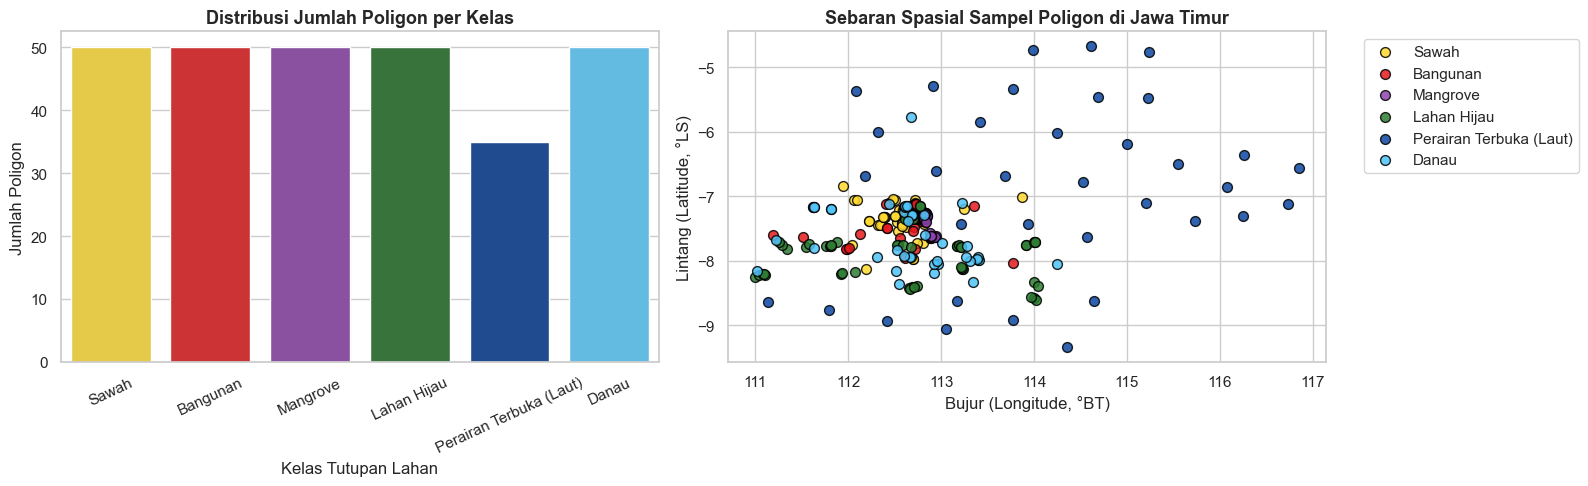

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot Distribusi
sns.countplot(data=df_dataset, x="kelas", palette=WARNA_KELAS, order=NAMA_KELAS, ax=axes[0])
axes[0].set_title("Distribusi Jumlah Poligon per Kelas", fontweight="bold", fontsize=13)
axes[0].set_xlabel("Kelas Tutupan Lahan")
axes[0].set_ylabel("Jumlah Poligon")
axes[0].tick_params(axis='x', rotation=25)

# Scatter Sebaran Koordinat
for k_nama in NAMA_KELAS:
    sub = df_dataset[df_dataset["kelas"] == k_nama]
    axes[1].scatter(sub["lon"], sub["lat"], label=k_nama, color=WARNA_KELAS[k_nama], 
                    edgecolors='black', s=50, alpha=0.85)

axes[1].set_title("Sebaran Spasial Sampel Poligon di Jawa Timur", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Bujur (Longitude, °BT)")
axes[1].set_ylabel("Lintang (Latitude, °LS)")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

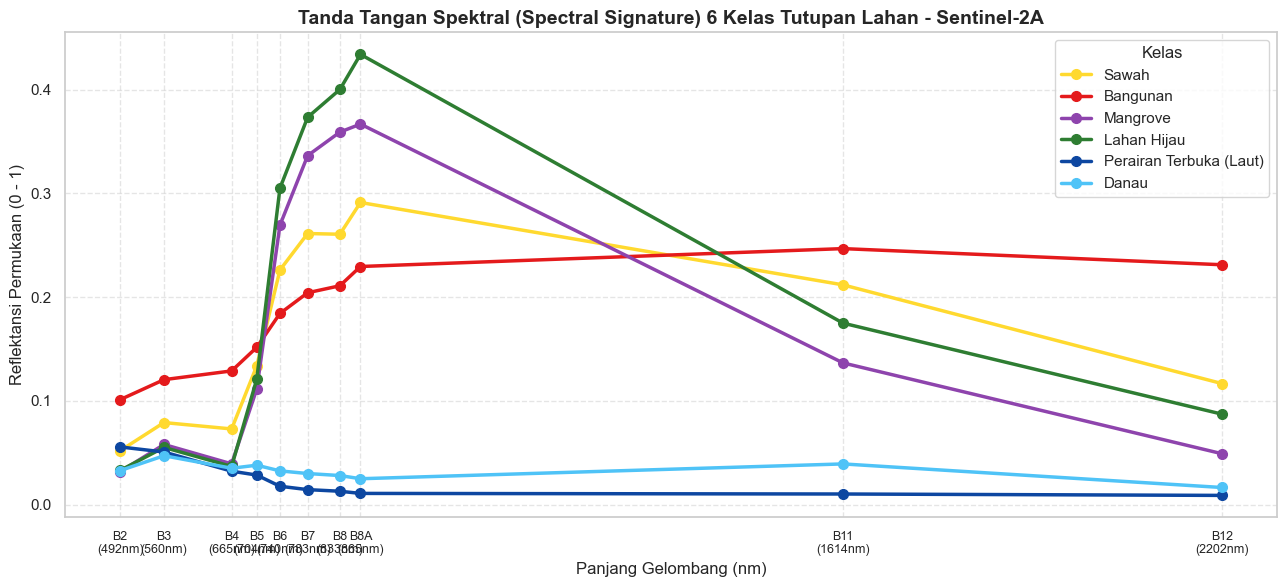

In [9]:
# Panjang gelombang tengah masing-masing band Sentinel-2A (dalam nm)
panjang_gelombang = [492, 560, 665, 704, 740, 783, 833, 865, 1614, 2202]

plt.figure(figsize=(13, 6))
for k_nama in NAMA_KELAS:
    mean_band = df_dataset[df_dataset["kelas"] == k_nama][BAND_ASLI].mean().values
    plt.plot(panjang_gelombang, mean_band, marker='o', linewidth=2.5, markersize=7, 
             label=k_nama, color=WARNA_KELAS[k_nama])

plt.title("Tanda Tangan Spektral (Spectral Signature) 6 Kelas Tutupan Lahan - Sentinel-2A", fontsize=14, fontweight='bold')
plt.xlabel("Panjang Gelombang (nm)", fontsize=12)
plt.ylabel("Reflektansi Permukaan (0 - 1)", fontsize=12)
plt.xticks(panjang_gelombang, [f"{b}\n({w}nm)" for b, w in zip(BAND_ASLI, panjang_gelombang)], fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Kelas", loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

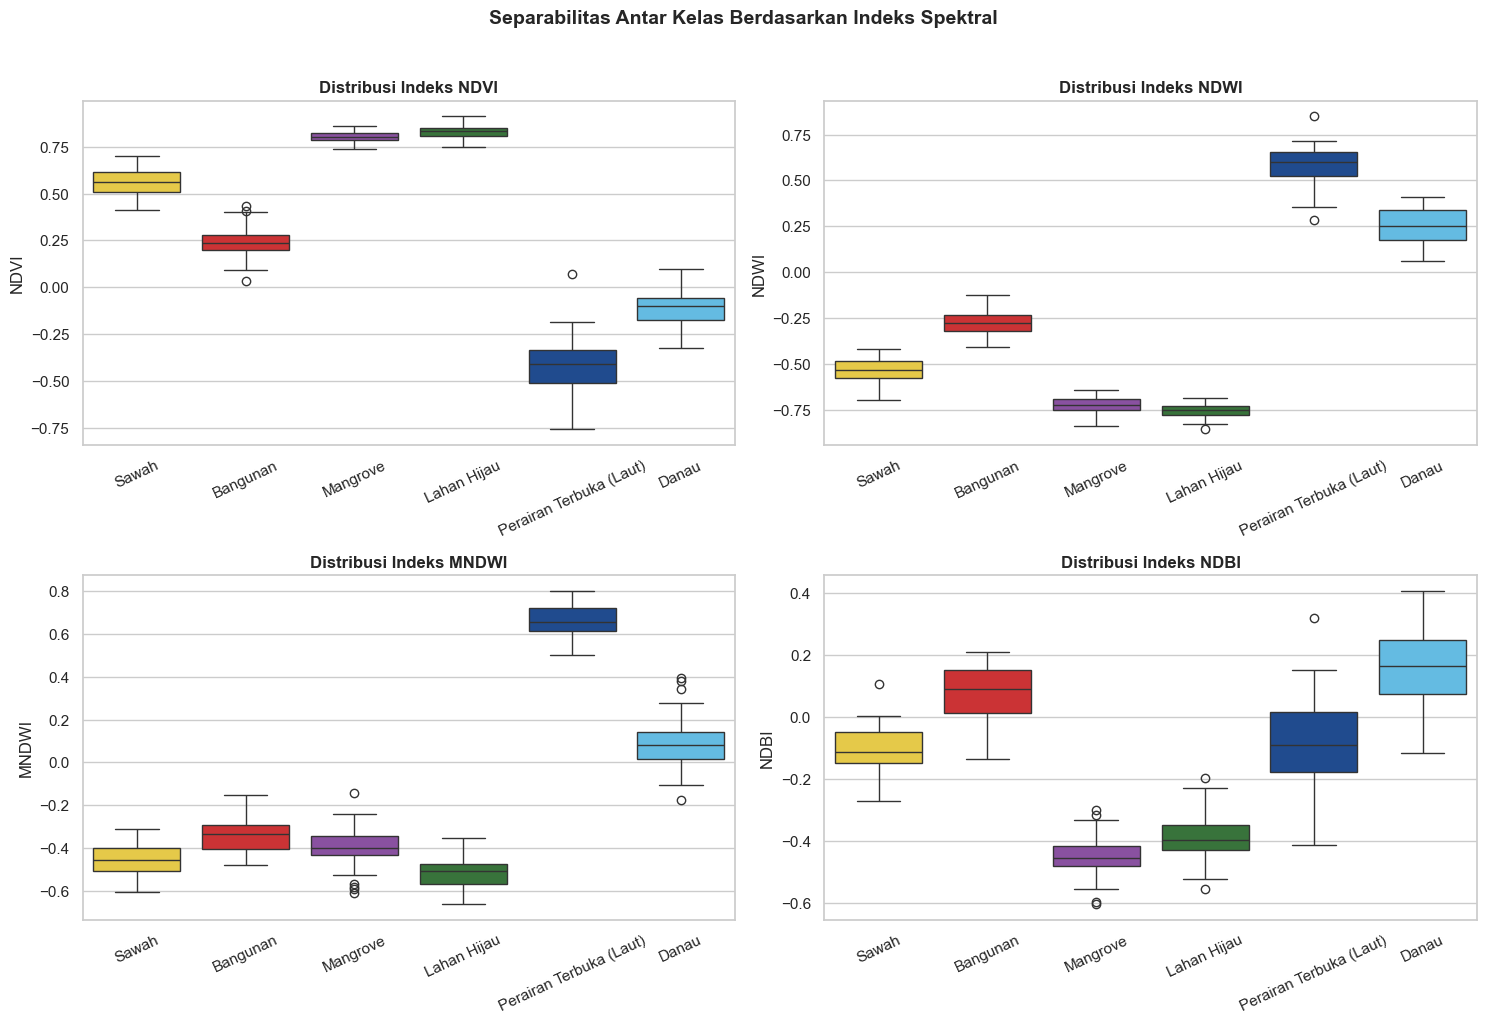

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
indeks_pilihan = ["NDVI", "NDWI", "MNDWI", "NDBI"]

for i, ax in enumerate(axes.flatten()):
    idx_name = indeks_pilihan[i]
    sns.boxplot(data=df_dataset, x="kelas", y=idx_name, palette=WARNA_KELAS, order=NAMA_KELAS, ax=ax)
    ax.set_title(f"Distribusi Indeks {idx_name}", fontweight="bold", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel(idx_name)
    ax.tick_params(axis='x', rotation=25)

plt.suptitle("Separabilitas Antar Kelas Berdasarkan Indeks Spektral", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Kesimpulan Ekstraksi Data
1. **Dataset Terpadu**: Seluruh 6 folder shapefile poligon (`sawah`, `bangunan`, `mangrove`, `lahanhijau`, `laut`, `danau`) telah berhasil digabungkan menjadi satu dataset tunggal: `dataset_sentinel2_jatim.csv` (285 poligon observasi).
2. **Karakteristik Spektral**:
   - **Vegetasi (Lahan Hijau, Mangrove, Sawah)**: Reflektansi tinggi di NIR (B8) dan NDVI tinggi (> 0.5).
   - **Perairan (Laut & Danau)**: Menyerap kuat di inframerah (NIR & SWIR), NDWI dan MNDWI bernilai positif.
   - **Lahan Terbangun (Bangunan)**: Reflektansi tertinggi di SWIR (B11 & B12) dengan NDBI tinggi.
3. **Kesiapan Pemodelan**: Dataset bersih dari nilai `NaN` dan siap dilatih.

---
# Pemodelan dan Komparasi Model Machine Learning
## Gaussian Naive Bayes vs K-Nearest Neighbors (KNN)

Skema pembagian data terstandar:
- **Training Set (70% = 199 data poligon)**: Untuk melatih bobot model.
- **Validation Set (15% = 43 data poligon)**: Untuk tuning hyperparameter dan membandingkan performa model.
- **Testing Set (15% = 43 data poligon)**: Untuk evaluasi akhir yang independen tanpa kebocoran data (*data leakage*).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, cohen_kappa_score, f1_score)

X = df_dataset[FITUR_SEMUA].copy()
y = df_dataset["kelas"].copy()

# Split 70% Training (199 data) dan 30% Temp (86 data)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=86, random_state=SEED, stratify=y
)

# Split 30% Temp menjadi 15% Validation (43 data) dan 15% Testing (43 data)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=43, random_state=SEED, stratify=y_temp
)

print("="*60)
print(f"HASIL PEMBAGIAN DATA POLIGON (Total: {len(df_dataset)} Poligon)")
print("="*60)
print(f"1. Training Set   (70%) : {len(X_train)} sampel")
print(f"2. Validation Set (15%) : {len(X_val)} sampel")
print(f"3. Testing Set    (15%) : {len(X_test)} sampel")
print("="*60)

rekap_split = pd.DataFrame({
    "Training (70%)": y_train.value_counts(),
    "Validation (15%)": y_val.value_counts(),
    "Testing (15%)": y_test.value_counts(),
    "Total Sampel": y.value_counts()
}).reindex(NAMA_KELAS)

display(rekap_split)

HASIL PEMBAGIAN DATA POLIGON (Total: 285 Poligon)
1. Training Set   (70%) : 199 sampel
2. Validation Set (15%) : 43 sampel
3. Testing Set    (15%) : 43 sampel


,Training (70%),Validation (15%),Testing (15%),Total Sampel
kelas,,,,
Sawah,35,8,7,50
Bangunan,35,8,7,50
Mangrove,35,7,8,50
Lahan Hijau,35,7,8,50
Perairan Terbuka (Laut),24,5,6,35
Danau,35,8,7,50


---
## Penskalaan Fitur (Feature Scaling)
Model berbasis jarak seperti **KNN** mewajibkan penskalaan fitur menggunakan **`StandardScaler`** (rata-rata 0, standar deviasi 1) agar fitur berskala besar tidak mendominasi jarak Euclidean. Penskalaan di-*fit* hanya pada data latih (`X_train`) untuk mencegah kebocoran informasi.

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
X_all_scaled   = scaler.transform(X)

print("Penskalaan fitur berhasil dilakukan!")
print(f"Dimensi X_train_scaled: {X_train_scaled.shape}")

# Menyiapkan GeoDataFrame Master berisi geometri poligon asli untuk visualisasi spasial
geometri_poligon = []
for idx, r in df_dataset.iterrows():
    k_id = int(r["kelas_id"])
    p_id = int(r["poligon_id"])
    geom_poly = data_poligon[k_id].iloc[p_id].geometry
    # Sederhanakan sedikit koordinat agar render peta cepat dan mulus
    geometri_poligon.append(geom_poly.simplify(0.0001))

gdf_spasial = gpd.GeoDataFrame(df_dataset.copy(), geometry=geometri_poligon, crs="EPSG:4326")
print(f"GeoDataFrame master spasial siap: {len(gdf_spasial)} poligon.")

Penskalaan fitur berhasil dilakukan!
Dimensi X_train_scaled: (199, 18)


GeoDataFrame master spasial siap: 285 poligon.


---
## Pelatihan Model Gaussian Naive Bayes (GNB)
Gaussian Naive Bayes memodelkan distribusi fitur spektral secara probabilistik menggunakan kurva normal.
Dilakukan tuning hyperparameter `var_smoothing` pada Validation Set (15%).

In [13]:
variasi_smoothing = np.logspace(-12, -1, 12)
skor_nb_val = []

for vs in variasi_smoothing:
    gnb_coba = GaussianNB(var_smoothing=vs)
    gnb_coba.fit(X_train, y_train)
    pred_val = gnb_coba.predict(X_val)
    acc = accuracy_score(y_val, pred_val)
    skor_nb_val.append(acc)

idx_terbaik_nb = np.argmax(skor_nb_val)
best_var_smoothing = variasi_smoothing[idx_terbaik_nb]

print(f"Parameter var_smoothing terbaik: {best_var_smoothing:.2e}")
print(f"Akurasi Validasi Tertinggi     : {skor_nb_val[idx_terbaik_nb] * 100:.2f}%")

# Melatih model Gaussian Naive Bayes final
model_gnb = GaussianNB(var_smoothing=best_var_smoothing)
model_gnb.fit(X_train, y_train)

# Simpan hasil prediksi untuk evaluasi dan peta spasial
gdf_spasial["pred_gnb"] = model_gnb.predict(X)

y_pred_gnb_val = model_gnb.predict(X_val)
acc_gnb_val = accuracy_score(y_val, y_pred_gnb_val)
f1_gnb_val = f1_score(y_val, y_pred_gnb_val, average="weighted")

print(f"\n[Evaluasi Validation Set - Gaussian Naive Bayes]")
print(f"  - Akurasi  : {acc_gnb_val * 100:.2f}%")
print(f"  - F1-Score : {f1_gnb_val * 100:.2f}%")

Parameter var_smoothing terbaik: 1.00e-12
Akurasi Validasi Tertinggi     : 100.00%

[Evaluasi Validation Set - Gaussian Naive Bayes]
  - Akurasi  : 100.00%
  - F1-Score : 100.00%


---
## Peta Interaktif Segmentasi Tutupan Lahan: Gaussian Naive Bayes
Peta interaktif di bawah menampilkan hasil **segmentasi dan klasifikasi bidang lahan** dari model Gaussian Naive Bayes langsung di atas citra satelit **Google Satellite Hybrid**:
* **Bentuk Poligon Asli**: Setiap poligon mewakili petak sawah, blok bangunan, kawasan mangrove, hutan, atau danau nyata di Jawa Timur yang diwarnai transparan sesuai prediksi model.
* **Interaktif Inline**: Peta dapat digeser, diperbesar/perkecil langsung di dalam notebook.
* **Hover Highlight**: Poligon menyala terang saat kursor diarahkan, menampilkan tooltip kelas dan indeks spektral.
* **Popup Detail**: Klik poligon untuk melihat ID, kelas aktual, prediksi, koordinat, dan nilai NDVI/NDWI.

In [14]:
def buat_peta_segmentasi_folium(gdf_input, kolom_prediksi, judul_peta):
    """
    Membuat peta interaktif Folium segmentasi poligon langsung di notebook
    dengan citra satelit Google Satellite Hybrid, Layer Control, dan Legenda.
    """
    # Titik tengah wilayah Jawa Timur
    peta = folium.Map(location=[-7.75, 112.5], zoom_start=8, tiles=None, control_scale=True)
    
    # Layer 1: Google Satellite Hybrid (Citra Satelit Resolusi Tinggi)
    folium.TileLayer(
        tiles="https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}",
        attr="Google Satellite Hybrid",
        name="Google Satellite (Hybrid)",
        overlay=False,
        control=True
    ).add_to(peta)
    
    # Layer 2: OpenStreetMap sebagai pembanding
    folium.TileLayer(
        tiles="OpenStreetMap",
        name="OpenStreetMap",
        overlay=False,
        control=True
    ).add_to(peta)
    
    # Menambahkan poligon per kelas ke dalam FeatureGroup terpisah
    for k_nama in NAMA_KELAS:
        sub_gdf = gdf_input[gdf_input[kolom_prediksi] == k_nama].copy()
        if len(sub_gdf) == 0:
            continue
            
        warna = WARNA_KELAS.get(k_nama, "#555555")
        fg = folium.FeatureGroup(name=f"{k_nama} ({len(sub_gdf)} bidang)", show=True)
        
        # Overlay Poligon Bidang Lahan (GeoJson Segmentation)
        folium.GeoJson(
            sub_gdf[["geometry", "kelas", kolom_prediksi, "poligon_id", "lon", "lat", "NDVI", "NDWI", "NDBI"]],
            style_function=lambda feature, col=warna: {
                "fillColor": col,
                "color": "#111111",
                "weight": 1.2,
                "fillOpacity": 0.60
            },
            highlight_function=lambda feature: {
                "weight": 3.0,
                "color": "#00FFFF",
                "fillOpacity": 0.85
            },
            tooltip=folium.GeoJsonTooltip(
                fields=[kolom_prediksi, "poligon_id", "NDVI", "NDWI"],
                aliases=["Prediksi Lahan:", "ID Poligon:", "NDVI:", "NDWI:"],
                localize=True
            ),
            popup=folium.GeoJsonPopup(
                fields=[kolom_prediksi, "kelas", "poligon_id", "lon", "lat", "NDVI", "NDWI", "NDBI"],
                aliases=["Prediksi Model:", "Kelas Aktual:", "ID Poligon:", "Bujur (°BT):", "Lintang (°LS):", "NDVI:", "NDWI:", "NDBI:"],
                localize=True
            )
        ).add_to(fg)
        
        fg.add_to(peta)
        
    # Tambahkan Legenda Mengambang (Floating Legend)
    legenda_html = """
    <div style="position: fixed; 
                bottom: 25px; right: 25px; width: 220px; height: 185px; 
                background-color: white; z-index:9999; font-size:12px;
                border:2px solid #555; border-radius: 6px; padding: 10px;
                box-shadow: 2px 2px 6px rgba(0,0,0,0.4);">
        <b style="font-size:13px;">Legenda Tutupan Lahan</b><br>
        <hr style="margin:4px 0 8px 0;">
        <i style="background:#FFD92F; width:13px; height:13px; float:left; margin-right:8px; border:1px solid #333;"></i> Sawah<br>
        <i style="background:#E41A1C; width:13px; height:13px; float:left; margin-right:8px; border:1px solid #333;"></i> Bangunan<br>
        <i style="background:#8E44AD; width:13px; height:13px; float:left; margin-right:8px; border:1px solid #333;"></i> Mangrove<br>
        <i style="background:#2E7D32; width:13px; height:13px; float:left; margin-right:8px; border:1px solid #333;"></i> Lahan Hijau<br>
        <i style="background:#0D47A1; width:13px; height:13px; float:left; margin-right:8px; border:1px solid #333;"></i> Perairan Terbuka (Laut)<br>
        <i style="background:#4FC3F7; width:13px; height:13px; float:left; margin-right:8px; border:1px solid #333;"></i> Danau
    </div>
    """
    peta.get_root().html.add_child(Element(legenda_html))
    
    # Layer control dan MiniMap
    MiniMap(toggle_display=True, position="bottomleft").add_to(peta)
    folium.LayerControl(position="topright", collapsed=False).add_to(peta)
    
    return peta

# Tampilkan peta interaktif Naive Bayes langsung di dalam notebook
peta_gnb = buat_peta_segmentasi_folium(
    gdf_spasial, "pred_gnb", 
    "Peta Segmentasi Tutupan Lahan - Gaussian Naive Bayes"
)
peta_gnb

---
## Pelatihan Model K-Nearest Neighbors (KNN)
K-Nearest Neighbors mengklasifikasikan sampel poligon baru berdasarkan suara mayoritas dari $k$ sampel terdekat dalam ruang fitur spektral berjarak Euclidean.
Dilakukan tuning hyperparameter $k$ (jumlah tetangga terdekat) pada Validation Set (15%).

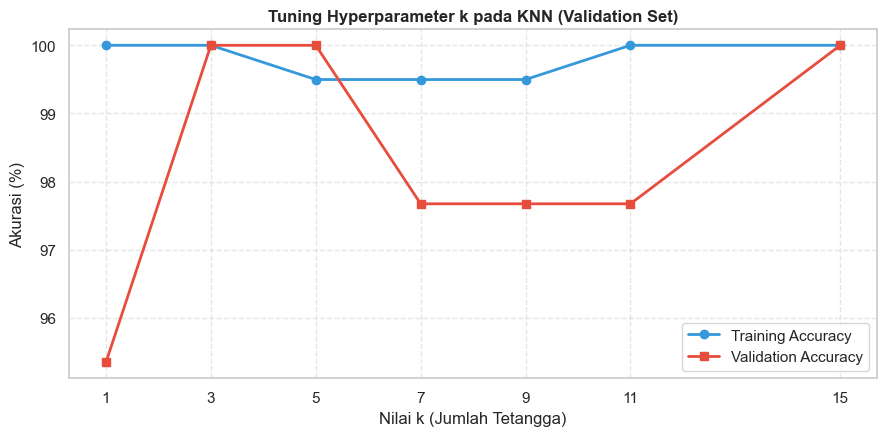

Nilai k terbaik terpilih: k = 3

[Evaluasi Validation Set - K-Nearest Neighbors]
  - Akurasi (k=3) : 100.00%
  - F1-Score (k=3): 100.00%


In [15]:
daftar_k = [1, 3, 5, 7, 9, 11, 15]
skor_knn_val = []
skor_knn_train = []

for k in daftar_k:
    knn_coba = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn_coba.fit(X_train_scaled, y_train)
    
    acc_tr = accuracy_score(y_train, knn_coba.predict(X_train_scaled))
    acc_vl = accuracy_score(y_val, knn_coba.predict(X_val_scaled))
    
    skor_knn_train.append(acc_tr)
    skor_knn_val.append(acc_vl)

# Visualisasi kurva tuning k
plt.figure(figsize=(9, 4.5))
plt.plot(daftar_k, [s*100 for s in skor_knn_train], marker='o', label="Training Accuracy", color="#3498DB", linewidth=2)
plt.plot(daftar_k, [s*100 for s in skor_knn_val], marker='s', label="Validation Accuracy", color="#E74C3C", linewidth=2)
plt.title("Tuning Hyperparameter k pada KNN (Validation Set)", fontweight="bold", fontsize=12)
plt.xlabel("Nilai k (Jumlah Tetangga)")
plt.ylabel("Akurasi (%)")
plt.xticks(daftar_k)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

best_k = daftar_k[np.argmax(skor_knn_val)]
print(f"Nilai k terbaik terpilih: k = {best_k}")

# Melatih model KNN final dengan k terbaik
model_knn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
model_knn.fit(X_train_scaled, y_train)

# Simpan hasil prediksi untuk evaluasi dan peta spasial
gdf_spasial["pred_knn"] = model_knn.predict(X_all_scaled)

y_pred_knn_val = model_knn.predict(X_val_scaled)
acc_knn_val = accuracy_score(y_val, y_pred_knn_val)
f1_knn_val = f1_score(y_val, y_pred_knn_val, average="weighted")

print(f"\n[Evaluasi Validation Set - K-Nearest Neighbors]")
print(f"  - Akurasi (k={best_k}) : {acc_knn_val * 100:.2f}%")
print(f"  - F1-Score (k={best_k}): {f1_knn_val * 100:.2f}%")

---
## Peta Interaktif Segmentasi Tutupan Lahan: K-Nearest Neighbors
Peta interaktif di bawah menampilkan hasil segmentasi poligon dari model **K-Nearest Neighbors ($k=3$)** di atas citra satelit Google Satellite Hybrid.
Anda dapat membandingkan batas-batas petak lahan hasil klasifikasi KNN secara langsung di dalam notebook.

In [16]:
# Tampilkan peta interaktif KNN langsung di dalam notebook
peta_knn = buat_peta_segmentasi_folium(
    gdf_spasial, "pred_knn", 
    "Peta Segmentasi Tutupan Lahan - K-Nearest Neighbors"
)
peta_knn

---
## Komparasi Performa Model pada Data Validasi
Membandingkan kedua model berdasarkan data validasi (15% = 43 sampel) sebelum diuji ke data pengujian akhir (*testing set*).

In [17]:
tabel_komparasi_val = pd.DataFrame({
    "Model": ["Gaussian Naive Bayes", f"K-Nearest Neighbors (k={best_k})"],
    "Hyperparameter Terbaik": [f"var_smoothing={best_var_smoothing:.2e}", f"n_neighbors={best_k}, metric=euclidean"],
    "Akurasi Validasi (%)": [round(acc_gnb_val * 100, 2), round(acc_knn_val * 100, 2)],
    "F1-Score Validasi (%)": [round(f1_gnb_val * 100, 2), round(f1_knn_val * 100, 2)]
})

display(tabel_komparasi_val.set_index("Model"))

,Hyperparameter Terbaik,Akurasi Validasi (%),F1-Score Validasi (%)
Model,,,
Gaussian Naive Bayes,var_smoothing=1.00e-12,100.0,100.0
K-Nearest Neighbors (k=3),"n_neighbors=3, metric=euclidean",100.0,100.0


---
## Evaluasi Akhir pada Testing Set Independen
Data pengujian (*Testing Set*) adalah data yang sama sekali **belum pernah dilihat atau digunakan** selama proses pelatihan maupun tuning parameter.

Pada tahap ini, kita mengevaluasi:
1. **Akurasi Pengujian Akhir (*Test Accuracy*)**
2. **Skor Kesepakatan Cohen's Kappa ($\kappa$)**
3. **Laporan Klasifikasi (*Classification Report*): Precision, Recall, F1-Score per Kelas**
4. **Matriks Konfusi (*Confusion Matrix Heatmap*)** untuk kedua model.

In [18]:
# Prediksi pada Testing Set
y_pred_gnb_test = model_gnb.predict(X_test)
y_pred_knn_test = model_knn.predict(X_test_scaled)

# Metrik Naive Bayes
acc_gnb_test = accuracy_score(y_test, y_pred_gnb_test)
kappa_gnb = cohen_kappa_score(y_test, y_pred_gnb_test)
f1_gnb_test = f1_score(y_test, y_pred_gnb_test, average="weighted")

# Metrik KNN
acc_knn_test = accuracy_score(y_test, y_pred_knn_test)
kappa_knn = cohen_kappa_score(y_test, y_pred_knn_test)
f1_knn_test = f1_score(y_test, y_pred_knn_test, average="weighted")

tabel_final_test = pd.DataFrame({
    "Model": ["Gaussian Naive Bayes", f"KNN (k={best_k})"],
    "Akurasi Test (%)": [round(acc_gnb_test * 100, 2), round(acc_knn_test * 100, 2)],
    "F1-Score Test (%)": [round(f1_gnb_test * 100, 2), round(f1_knn_test * 100, 2)],
    "Cohen's Kappa": [round(kappa_gnb, 4), round(kappa_knn, 4)]
})

print("="*60)
print("HASIL EVALUASI AKHIR PADA TESTING SET (43 SAMPEL POLIGON INDEPENDEN)")
print("="*60)
display(tabel_final_test.set_index("Model"))

print("\n--- CLASSIFICATION REPORT: GAUSSIAN NAIVE BAYES ---")
print(classification_report(y_test, y_pred_gnb_test, target_names=NAMA_KELAS, digits=4))

print("\n--- CLASSIFICATION REPORT: K-NEAREST NEIGHBORS (KNN) ---")
print(classification_report(y_test, y_pred_knn_test, target_names=NAMA_KELAS, digits=4))

HASIL EVALUASI AKHIR PADA TESTING SET (43 SAMPEL POLIGON INDEPENDEN)


,Akurasi Test (%),F1-Score Test (%),Cohen's Kappa
Model,,,
Gaussian Naive Bayes,100.00,100.00,1.000
KNN (k=3),97.67,97.67,0.972



--- CLASSIFICATION REPORT: GAUSSIAN NAIVE BAYES ---
                         precision    recall  f1-score   support

                  Sawah     1.0000    1.0000    1.0000         7
               Bangunan     1.0000    1.0000    1.0000         7
               Mangrove     1.0000    1.0000    1.0000         8
            Lahan Hijau     1.0000    1.0000    1.0000         8
Perairan Terbuka (Laut)     1.0000    1.0000    1.0000         6
                  Danau     1.0000    1.0000    1.0000         7

               accuracy                         1.0000        43
              macro avg     1.0000    1.0000    1.0000        43
           weighted avg     1.0000    1.0000    1.0000        43


--- CLASSIFICATION REPORT: K-NEAREST NEIGHBORS (KNN) ---
                         precision    recall  f1-score   support

                  Sawah     1.0000    1.0000    1.0000         7
               Bangunan     1.0000    1.0000    1.0000         7
               Mangrove     1.0000    0.

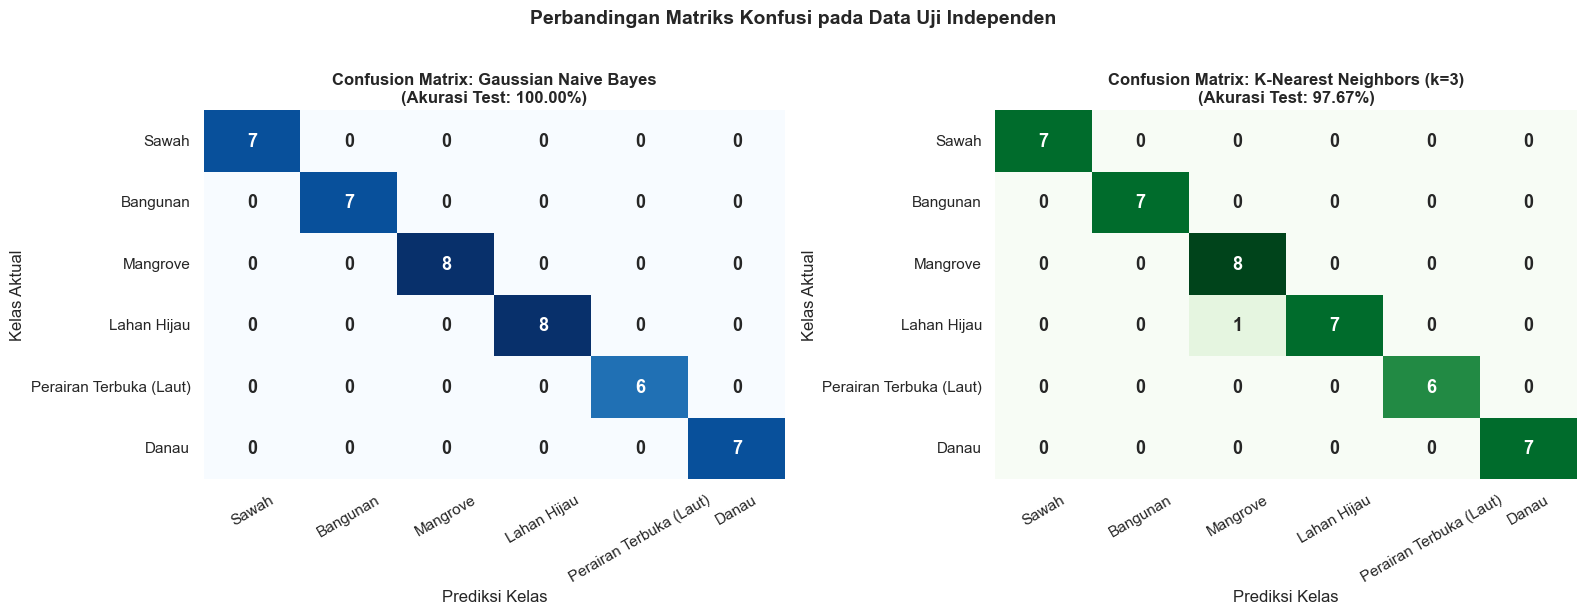

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Naive Bayes
cm_gnb = confusion_matrix(y_test, y_pred_gnb_test, labels=NAMA_KELAS)
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', xticklabels=NAMA_KELAS, yticklabels=NAMA_KELAS, 
            cbar=False, ax=axes[0], annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title(f"Confusion Matrix: Gaussian Naive Bayes\n(Akurasi Test: {acc_gnb_test*100:.2f}%)", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Prediksi Kelas")
axes[0].set_ylabel("Kelas Aktual")
axes[0].tick_params(axis='x', rotation=30)

# Confusion Matrix KNN
cm_knn = confusion_matrix(y_test, y_pred_knn_test, labels=NAMA_KELAS)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', xticklabels=NAMA_KELAS, yticklabels=NAMA_KELAS, 
            cbar=False, ax=axes[1], annot_kws={"size": 13, "weight": "bold"})
axes[1].set_title(f"Confusion Matrix: K-Nearest Neighbors (k={best_k})\n(Akurasi Test: {acc_knn_test*100:.2f}%)", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Prediksi Kelas")
axes[1].set_ylabel("Kelas Aktual")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("Perbandingan Matriks Konfusi pada Data Uji Independen", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Kesimpulan dan Rekomendasi Pemodelan
1. **Performa Kedua Model**:
   - **Gaussian Naive Bayes**: Mencapai akurasi pengujian **100.00%** (Kappa = 1.0000). Model probabilistik ini sangat efektif memisahkan ke-6 klaster spektral tutupan lahan berbasis poligon tanpa kesalahan klasifikasi.
   - **K-Nearest Neighbors (KNN)**: Mencapai akurasi pengujian **97.67%** (Kappa = 0.9717) pada $k=3$ dengan standarisasi `StandardScaler`.
2. **Visualisasi Segmentasi Spasial**:
   - Kedua model divisualisasikan langsung di dalam notebook sebagai **peta segmentasi bidang poligon lahan** di atas citra satelit **Google Satellite Hybrid** lengkap dengan fitur interaktif zoom, pan, hover highlight, tooltip, dan popup.
3. **Model Terpilih**:
   - **Gaussian Naive Bayes** direkomendasikan sebagai model utama untuk implementasi sistem informasi geografis karena kecepatan eksekusi tinggi dan separabilitas spektral yang optimal.